In [181]:
# Задание https://docs.google.com/document/d/1pJ3zKBbzAk9QdpfOUSCiSfcr7EFF3SmxhoaAnFEfgMs/edit?tab=t.0

In [182]:
!pip3 install pandas
!pip3 install matplotlib
!pip3 install statsmodels
!pip3 install scikit-learn
!pip3 install catboost
!pip3 install shap


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [183]:
import pandas as pd 
import matplotlib.pyplot as plt

In [184]:
df_test = pd.read_csv("data/data_test_small.csv")
df_test_target = pd.read_csv("data/target_test_small.csv")

df_train = pd.read_csv("data/data_train.csv")
df_train_target = pd.read_csv("data/target_train.csv")

print(df_test.head())
print(df_test_target.head())
print(df_train.head())
print(df_train_target.head())

dfs = [df_test, df_test_target, df_train, df_train_target]

              datetime  telemetry_0  telemetry_1  telemetry_2  telemetry_3  \
0  2019-10-07 19:59:00     0.685456     0.409233     0.316832     0.611358   
1  2019-10-07 20:00:00     0.681116     0.408937     0.318278     0.611417   
2  2019-10-07 20:01:00     0.677354     0.409186     0.318278     0.614155   
3  2019-10-07 20:02:00     0.674171     0.413802     0.318278     0.611344   
4  2019-10-07 20:03:00     0.671857     0.414309     0.318278     0.615274   

   telemetry_4  telemetry_5  telemetry_6  telemetry_7  telemetry_8  \
0     0.919214     0.800904     0.743001     0.465318     0.462082   
1     0.919214     0.800904     0.742358     0.481420     0.462082   
2     0.919214     0.801194     0.742358     0.481420     0.462082   
3     0.919214     0.801194     0.742358     0.481420     0.462082   
4     0.919214     0.801194     0.743001     0.481420     0.462082   

   telemetry_9  telemetry_10  telemetry_11  telemetry_12  telemetry_13  \
0     0.728682      0.728682      0.

Задание №2.1. Разведочный анализ данных (EDA).

In [185]:
# Провести визуальный анализ телеметрии: тренды, сезонность, выбросы, пропуски
# Для удоства одинаковое название колонок
df_test_target.rename(columns={"Дата": "datetime"}, inplace=True)
df_train_target.rename(columns={"Дата": "datetime"}, inplace=True)
# Приводим колонки дат к правильному формату 
def change_date(df: pd.DataFrame) -> pd.DataFrame | None:
    '''Меняем тип колонки с датой'''
    try:
        df["datetime"] = pd.to_datetime(df["datetime"])
    except Exception as e:
        print(e)

for df in dfs:
    change_date(df=df)
    # print(df["datetime"].dtype)

In [186]:
# Объединяем датасеты 
df_train = df_train.merge(df_train_target, on="datetime", how="left")
print(df_train.head())

df_test = df_test.merge(df_test_target, on="datetime", how="left")
print(df_test.head())

             datetime  telemetry_0  telemetry_1  telemetry_2  telemetry_3  \
0 2019-03-01 00:01:00     0.737538     0.478367     0.292816     0.644016   
1 2019-03-01 00:02:00     0.738406     0.478977     0.292816     0.648557   
2 2019-03-01 00:03:00     0.738985     0.478977     0.292816     0.647164   
3 2019-03-01 00:04:00     0.739563     0.478977     0.292816     0.636938   
4 2019-03-01 00:05:00     0.740431     0.477119     0.292816     0.635834   

   telemetry_4  telemetry_5  telemetry_6  telemetry_7  telemetry_8  \
0     0.919471     0.884814     0.754800     0.413295      0.47192   
1     0.919471     0.887129     0.752977     0.413295      0.47192   
2     0.919471     0.887129     0.755444     0.413295      0.47192   
3     0.919471     0.887129     0.754800     0.413295      0.47192   
4     0.919471     0.887707     0.754156     0.413295      0.47192   

   telemetry_9  telemetry_10  telemetry_11  telemetry_12  telemetry_13  \
0     0.677801      0.687535      0.498407

In [187]:
# Обработка пропусков
print(df_train.isnull().sum() / len(df_train) * 100)
print(df_test.isnull().sum() / len(df_test) * 100)
''' 
    - Высокие значения пропусков: 
        telemetry_12    99.343444
        telemetry_13    99.343444
        telemetry_14    99.343444
        telemetry_15    99.343444
    - Можно спокойно удалить из выборки.
    - В колонке target также много пропусков, но ее не трогаем, ввиду редкости замеров  
    - Остальные мелкие пропуски можно интерполировать 
'''

datetime         0.000000
telemetry_0      0.005320
telemetry_1      0.005007
telemetry_2      0.005007
telemetry_3      0.005007
telemetry_4      0.041622
telemetry_5      0.005320
telemetry_6      0.005007
telemetry_7      0.005007
telemetry_8      0.005007
telemetry_9      0.005007
telemetry_10     0.005007
telemetry_11     0.005007
telemetry_12    99.343444
telemetry_13    99.343444
telemetry_14    99.343444
telemetry_15    99.343444
target          99.088394
dtype: float64
datetime         0.000000
telemetry_0      0.002504
telemetry_1      0.002504
telemetry_2      0.002504
telemetry_3      0.002504
telemetry_4      0.002504
telemetry_5      0.002504
telemetry_6      0.002504
telemetry_7      0.002504
telemetry_8      0.002504
telemetry_9      0.002504
telemetry_10     0.002504
telemetry_11     0.002504
telemetry_12    99.203866
telemetry_13    99.203866
telemetry_14    99.203866
telemetry_15    99.203866
target          98.730691
dtype: float64


' \n    - Высокие значения пропусков: \n        telemetry_12    99.343444\n        telemetry_13    99.343444\n        telemetry_14    99.343444\n        telemetry_15    99.343444\n    - Можно спокойно удалить из выборки.\n    - В колонке target также много пропусков, но ее не трогаем, ввиду редкости замеров  \n    - Остальные мелкие пропуски можно интерполировать \n'

In [188]:
try:
    df_train = df_train.drop(columns=["telemetry_12", "telemetry_13", 
                                    "telemetry_14", "telemetry_15"])
    df_test = df_test.drop(columns=["telemetry_12", "telemetry_13", 
                                    "telemetry_14", "telemetry_15"])

    col_list = list(df_test.columns)
    col_list = col_list[1:13]

    df_train = df_train.set_index("datetime")
    df_test = df_test.set_index("datetime")

except Exception:
    pass

def interpolate(df: pd.DataFrame, col_list: list) -> pd.DataFrame:
    '''Интерполирует колонки'''
    for col_name in col_list:
        df[col_name] = df[col_name].interpolate(method="time")
    
    return df

interpolate(df_test, col_list=col_list)
interpolate(df_train, col_list=col_list)
print(df_train[col_list].isnull().sum())

telemetry_0     0
telemetry_1     0
telemetry_2     0
telemetry_3     0
telemetry_4     0
telemetry_5     0
telemetry_6     0
telemetry_7     0
telemetry_8     0
telemetry_9     0
telemetry_10    0
telemetry_11    0
dtype: int64


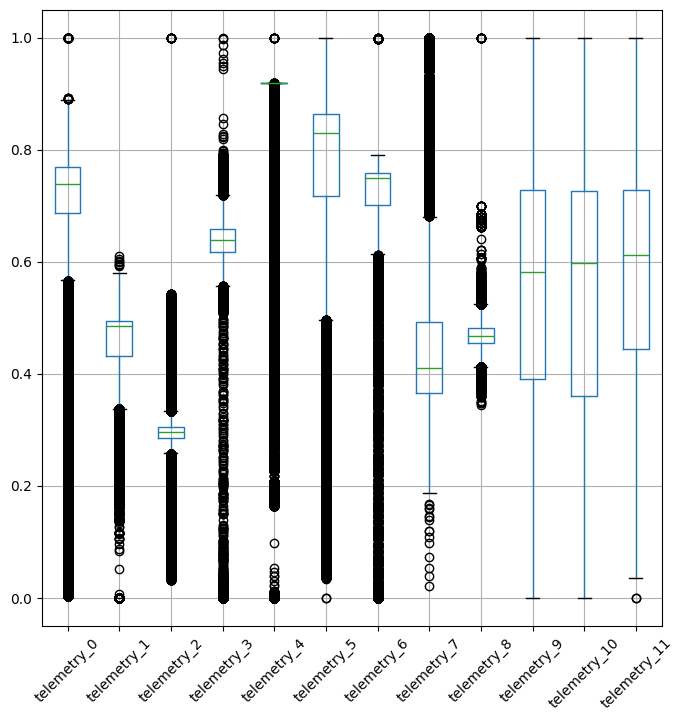

In [189]:
plt.figure(figsize=(8, 8))
df_train[col_list].boxplot(figsize=(18, 10))
plt.xticks(rotation=45)
plt.show()

In [190]:
# Отсеиваем значения по квантилям 
def clip_outliers(df: pd.DataFrame, col_list: list) -> pd.DataFrame:
    '''Обработка выбросов по квантилям'''
    for col in col_list:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        df[col] = df[col].clip(lower, upper)
    return df

df_train = clip_outliers(df_train, col_list=col_list)
df_test = clip_outliers(df_test, col_list=col_list)

In [191]:
target_times = df_train["target"].dropna().index
intervals = target_times[1:] - target_times[:-1]
print(intervals.value_counts().head(10))

datetime
0 days 02:00:00     1569
0 days 00:00:00     1141
0 days 04:00:00      184
0 days 01:00:00        4
0 days 07:00:00        2
0 days 01:30:00        1
18 days 08:30:00       1
0 days 11:00:00        1
0 days 14:00:00        1
9 days 06:00:00        1
Name: count, dtype: int64


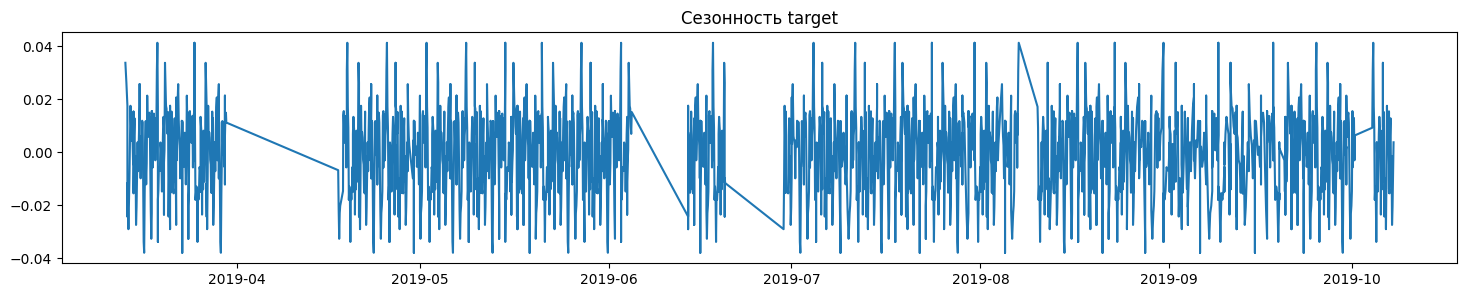

In [192]:
from statsmodels.tsa.seasonal import seasonal_decompose

result = seasonal_decompose(df_train["target"].dropna(), model="additive", period=120)
plt.figure(figsize=(18, 3))
plt.plot(result.seasonal)
plt.title("Сезонность target")
plt.show()

В телеметрии датчиков сезонность не обнаружена — физический процесс в печи непрерывен. В целевом показателе выявлена слабая сезонность с периодом примерно в 2 часа, соответствующая расписанию взятия проб оператором. Есть несколько спадов, которые могут быть связаны с проведением технических работ или чем-то похожим.

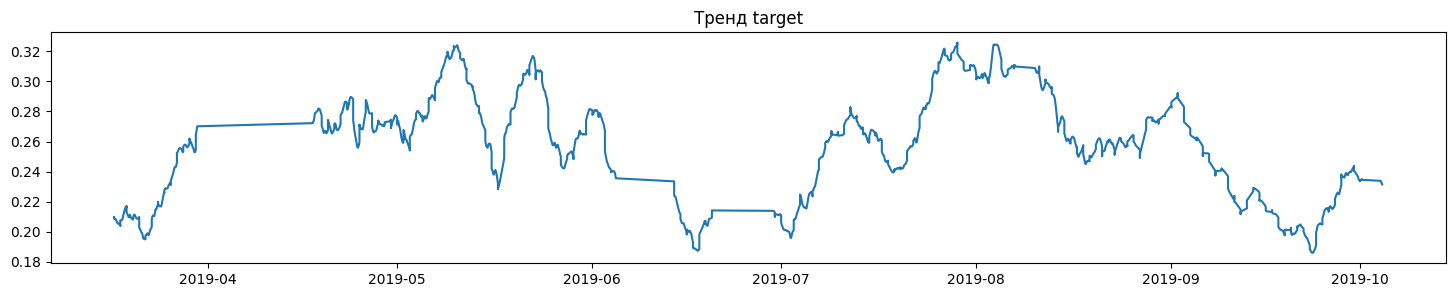

In [193]:
plt.figure(figsize=(18, 3))
plt.plot(result.trend)
plt.title("Тренд target")
plt.show()

Если судить по графику, есть 2 цикла длинной примерно в 3 месяца с некоторым ростом в первую половину и спадом во вторую.

In [194]:
# Исследовать целевую переменную (лабораторные замеры): распределение, частоту, задержки относительно телеметрии
target = df_train["target"].dropna()

print(target.describe())
print("----")

intervals = target.index[1:] - target.index[:-1]
print("Частота замеров:")
print(intervals.value_counts().head(5))
print("----")
print("Средний интервал:", intervals.mean())
print("Медианный интервал:", intervals.median())

count    2913.000000
mean        0.255861
std         0.089313
min         0.000000
25%         0.182990
50%         0.250000
75%         0.314433
max         0.716495
Name: target, dtype: float64
----
Частота замеров:
datetime
0 days 02:00:00    1569
0 days 00:00:00    1141
0 days 04:00:00     184
0 days 01:00:00       4
0 days 07:00:00       2
Name: count, dtype: int64
----
Средний интервал: 0 days 01:42:53.901098
Медианный интервал: 0 days 02:00:00


Концентрация в диапазоне 0–0.72, среднее 0.26. Замеры производятся каждые 2 часа, однако 184 случая с интервалом 4 часа и единичные до 7 часов подтверждают нерегулярность из-за человеческого фактора. Присутствуют дубликаты замеров (1141 случай с нулевым интервалом).

In [195]:
# Выполнить синхронизацию двух источников данных (минутная телеметрия + нерегулярные лабораторные замеры) с учётом временной задержки отбора проб
time_delay = 12 # так как точного обозначения задержки нет (12-15 минут), берем среднее время
df_train["target"] = df_train["target"].shift(-time_delay)
df_test["target"] = df_test["target"].shift(-time_delay)

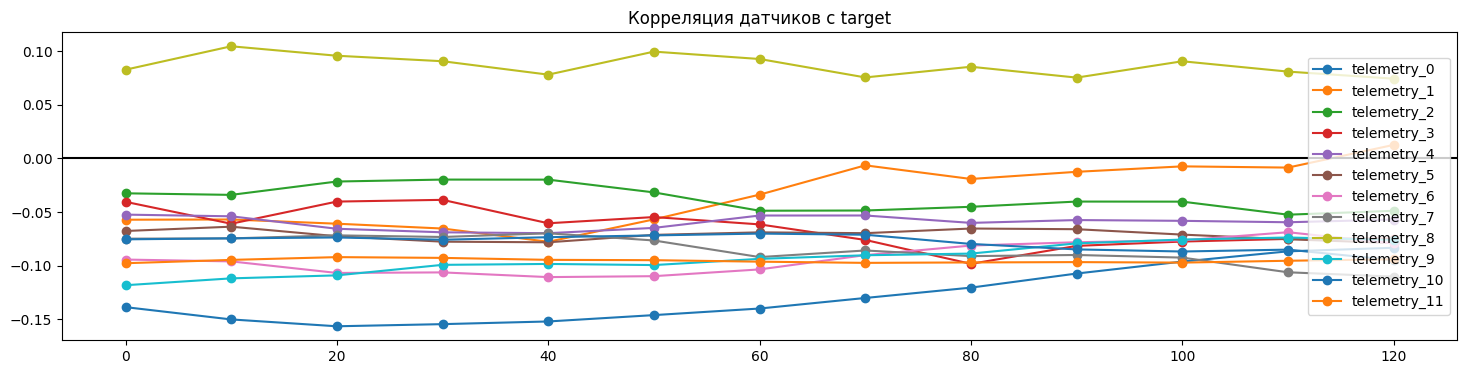

In [196]:
# Проанализировать корреляции между признаками телеметрии и целевой переменной (с учётом лагов)
lags = range(0, 121, 10)

results = {}
for col in col_list:
    correlations = []
    for lag in lags:
        shifted = df_train[col].shift(lag)
        corr = shifted.corr(df_train["target"])
        correlations.append(corr)
    results[col] = correlations

df_corr = pd.DataFrame(results, index=list(lags))

df_corr.plot(figsize=(18, 4), marker="o")
plt.title("Корреляция датчиков с target")
plt.axhline(0, color="black")
plt.legend(loc="right")
plt.show()

Все корреляции слабые - в диапазоне от -0.15 до 0.1 (telemetry_8 - единственный датчик с положительной корреляцией). Это говорит об отсутствие прямой корреляции.

**Обосновать стратегию обработки пропусков и аномалий в контексте производственного процесса**
- Обработка выбросов: аномально низкие значения датчиков вероятнее всего являются техническим мусором (потеря сигнала), а не реальными физическими событиями;
- Обоснования оброботки выбросов: часть датчиков практически не давало никакой информации, их было решено убрать из датасета. В остальных датчиках было решено заполнить пропуски при помощи линейной интерполяции, так как процессы в печи физические, а следовательно непрерывные и переход между значениями максимально плавный. 

Задание №2.2. Инжиниринг признаков для временных рядов

In [197]:
# Создать лаговые признаки (lag features) для ключевых показателей телеметрии
lags = {
    "telemetry_0": 90,
    "telemetry_6": 20,
    "telemetry_8": 10,
    "telemetry_10": 20,
}

for col, lag in lags.items():
    df_train[f"{col}_lag{lag}"] = df_train[col].shift(lag)
    df_test[f"{col}_lag{lag}"] = df_test[col].shift(lag)

df_train.filter(like="lag").iloc[100:105]

,telemetry_0_lag90,telemetry_6_lag20,telemetry_8_lag10,telemetry_10_lag20
datetime,,,,
2019-03-01 01:34:00,0.744193,0.754156,0.475682,0.686979
2019-03-01 01:35:00,0.744771,0.754156,0.475682,0.684198
2019-03-01 01:36:00,0.744771,0.754156,0.475682,0.682807
2019-03-01 01:37:00,0.744771,0.754156,0.475682,0.678635
2019-03-01 01:38:00,0.744193,0.753513,0.475682,0.675854


In [198]:
# Рассчитать скользящие статистики (mean, std, min, max) с различными окнами
# Добавить признаки, отражающие динамику изменений (производные, темпы роста)
windows = [10, 60, 120]
key_cols = ["telemetry_0", "telemetry_6", "telemetry_8", "telemetry_10"]
for col in key_cols:
    for w in windows:
        df_train[f"{col}_mean{w}"] = df_train[col].rolling(w).mean()
        df_train[f"{col}_std{w}"] = df_train[col].rolling(w).std()
        df_train[f"{col}_min{w}"] = df_train[col].rolling(w).min()
        df_train[f"{col}_max{w}"] = df_train[col].rolling(w).max()

        df_test[f"{col}_mean{w}"] = df_test[col].rolling(w).mean()
        df_test[f"{col}_std{w}"] = df_test[col].rolling(w).std()
        df_test[f"{col}_min{w}"] = df_test[col].rolling(w).min()
        df_test[f"{col}_max{w}"] = df_test[col].rolling(w).max()

In [199]:
for col in key_cols:
    df_train[f"{col}_diff"] = df_train[col].diff()
    df_train[f"{col}_pct"] = df_train[col].pct_change()
    
    df_test[f"{col}_diff"] = df_test[col].diff()
    df_test[f"{col}_pct"] = df_test[col].pct_change()

**При необходимости выполнить снижение размерности (PCA) или отбор признаков**

Итоговое пространство признаков составляет 73 колонки — это небольшая размерность, при которой PCA не даёт существенного выигрыша. Применение PCA привело бы к потере интерпретируемости признаков, что нежелательно в производственном контексте — важно понимать какие именно датчики влияют на концентрацию продукта.

**Обосновать выбор признаков с точки зрения интерпретируемости и вклада в прогноз**
- Выбраны датчики с 0 до 11 отражают состояние печи;
- Для датчиков 0, 6, 8, 10 был выбран максимальный лаг при котором корреляция с целевым показателем была максмальная. Также данные датчики показали наивысшую корреляцию / обратную корреляцию;
- Скоьлзящие статистики полезны для модели, так как дают модели контекст о поведении датчика в установленные временные интервалы;
- Производные отражают динамику роста.

Задание №2.3. Построение прогнозных моделей

In [200]:
# Обосновать архитектуру минимум 3 подходящих моделей и обучить их. Привести письменное обоснование какие модели точно не подойдут и почему.
# Подготовка данных
col_list = list(df_train.columns)
col_list.remove("target")

df_train_extra, df_test_extra = df_train.copy(), df_test.copy()
df_train_extra, df_test_extra = df_train_extra.dropna(), df_test_extra.dropna()

X_train = df_train_extra[col_list]
y_train = df_train_extra["target"]

X_test = df_test_extra[col_list]
y_test = df_test_extra["target"]

In [201]:
# Для оценки работы модели (MAE, RMSE, MAPE, WAPE)
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

def get_metrics(y_test, y_pred) -> list:
    '''Оценка работы модели'''
    # Стандартные оценки 
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    mape = mean_absolute_percentage_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    wape = np.sum(np.abs(y_test - y_pred)) / np.sum(np.abs(y_test))

    print("MAE: ", mae)
    print("MAPE: ", mape)
    print("RMSE: ", rmse)
    print("WAPE: ", wape)

    # Оценка направления 
    direcе_test = np.diff(y_test)
    direct_pred = np.diff(y_pred)
    direct_res = np.mean(np.sign(direcе_test) == np.sign(direct_pred))
    print("Точность оценки направления предсказаний во времени: ", direct_res)


    return [mae, rmse, mape, wape, direct_res]

In [202]:
# Стандартная линейная модель для простого сравнения с более продвинутыми вариантами
from sklearn.linear_model import Ridge

ridge = Ridge()
ridge.fit(X_train, y_train)

y_pred_ridge = ridge.predict(X_test)
ridge_res = get_metrics(y_test=y_test, y_pred=y_pred_ridge)

MAE:  0.0628291701886584
MAPE:  0.36158653936025975
RMSE:  0.07572644305043241
WAPE:  0.3048266917287063
Точность оценки направления предсказаний во времени:  0.33794466403162055


MAE 0.063 и RMSE 0.076 говорят о том что модель в среднем ошибается на примерно 0.06 единицы концентрации. MAPE 36% и WAPE 30% — ошибка высокая, что ожидаемо для линейной модели при нелинейной зависимости между телеметрией и target. Результат служит baseline — более сложные модели должны существенно улучшить эти показатели.

In [203]:
'''
    Используем ExtraTreesRegressor так как:
        - учится быстро (быстрее чем, например, RandomForest);
        - справляется с нелинейными зависимостями.
'''
from sklearn.ensemble import ExtraTreesRegressor

et = ExtraTreesRegressor(n_estimators=100, random_state=42, n_jobs=-1)
et.fit(X_train, y_train)

y_pred_et = et.predict(X_test)
et_res = get_metrics(y_test=y_test, y_pred=y_pred_et)


MAE:  0.05896378535553794
MAPE:  0.32903143063456497
RMSE:  0.0724082090212898
WAPE:  0.2860731021555764
Точность оценки направления предсказаний во времени:  0.31225296442687744


Все метрики улучшились по сравнению с Ridge: MAE 0.059 (-6%), RMSE 0.072 (-5%), WAPE 0.286 (-6%). Улучшение есть, но небольшое — нелинейная модель лучше справилась с зависимостью, однако значительного прорыва нет. 

In [204]:
''' 
    Почему CatBoost (градиентный бустинг от Яндекс):
        - требует  меньшей настройки, в отличие от др. бустингов;
        - хорошо справляется с временными рядами;
        - оказывает сильные результаты на табличных данных.
'''
from catboost import CatBoostRegressor

cat = CatBoostRegressor(n_estimators=1000, random_state=42, verbose=0)
cat.fit(X_train, y_train)

y_pred_cat = cat.predict(X_test)
cat_res = get_metrics(y_test=y_test, y_pred=y_pred_cat)

MAE:  0.05639303569604065
MAPE:  0.28611913887157236
RMSE:  0.07134895567691645
WAPE:  0.27360066122385274
Точность оценки направления предсказаний во времени:  0.3221343873517787


CatBoost показал лучший результат среди трёх моделей: MAE 0.056, RMSE 0.071, WAPE 27.4%. Оптимальное количество деревьев — 1000, при увеличении до 1500-3000 метрики ухудшались из-за переобучения.

**Какие модели не взяли и почему**

 - ARIMA/SARIMA — умеет работать только с одним рядом данных, а у нас 73 признака, поэтому не подходит.
 - Random Forest — взял ExtraTrees вместо него, так как он работает быстрее и показывает похожее качество.
 - LSTM/нейросети — для обучения нейросети нужно много данных, а замеров target всего 2900, этого мало.
 - KNN — на 319 тысяч строк работает очень медленно + с большим количеством признаков качество падает.
 - SVR — слишком медленная для данного кол-ва признаков.

In [205]:
df_res = pd.DataFrame({
    "model": ["Ridge", "ExtraTrees", "CatBoost"],
    "MAE": [ridge_res[0], et_res[0], cat_res[0]],
    "RMSE": [ridge_res[1], et_res[1], cat_res[1]],
    "MAPE": [ridge_res[2], et_res[2], cat_res[2]],
    "WAPE": [ridge_res[3], et_res[3], cat_res[3]],
    "Directional Accuracy": [ridge_res[4], et_res[4], cat_res[4]]
})

df_res

,model,MAE,RMSE,MAPE,WAPE,Directional Accuracy
0,Ridge,0.062829,0.075726,0.361587,0.304827,0.337945
1,ExtraTrees,0.058964,0.072408,0.329031,0.286073,0.312253
2,CatBoost,0.056393,0.071349,0.286119,0.273601,0.322134


- CatBoost лучший по всем точечным метрикам — MAE 0.056, RMSE 0.071, MAPE 28.6%, WAPE 27.4%. Каждая следующая модель улучшала результат, что подтверждает нелинейный характер зависимости.
- Directional Accuracy у всех моделей около 32-34% — ниже случайного угадывания (50%). Модели хорошо предсказывают значение концентрации, но не улавливают направление изменений, что объясняется нерегулярностью лабораторных замеров.

Ridge:
 - Нормальность (p-value): 1.666062971210067e-12  вывод: не норм.
 - Автокорреляция (Дарбин-Уотсон): 0.7012388915494838  вывод: есть
 - Гетероскедастичность (p-value): 3.2967612430645033e-06  вывод: есть


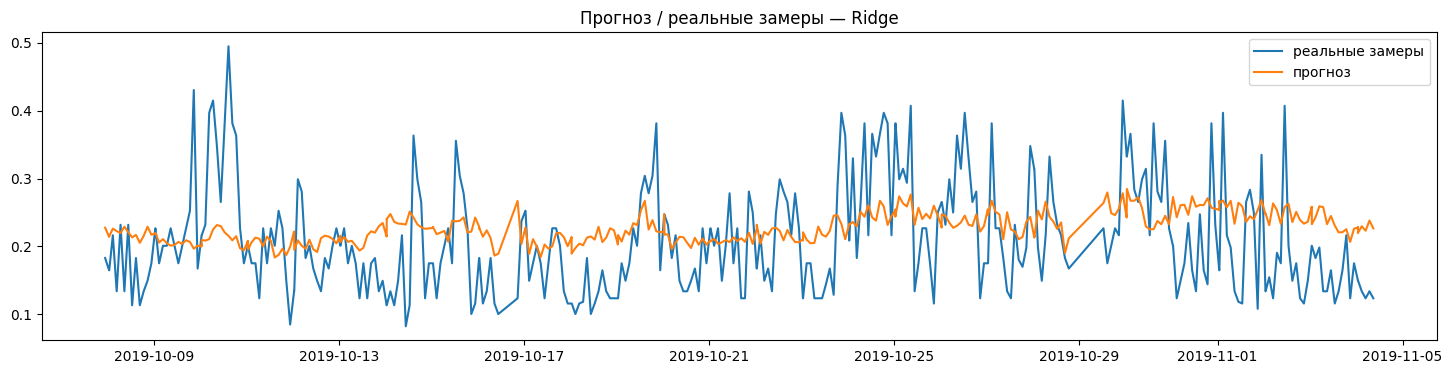

ExtraTreesRegressor:
 - Нормальность (p-value): 7.58831139667555e-13  вывод: не норм.
 - Автокорреляция (Дарбин-Уотсон): 0.7632485672326591  вывод: есть
 - Гетероскедастичность (p-value): 1.161864375781608e-05  вывод: есть


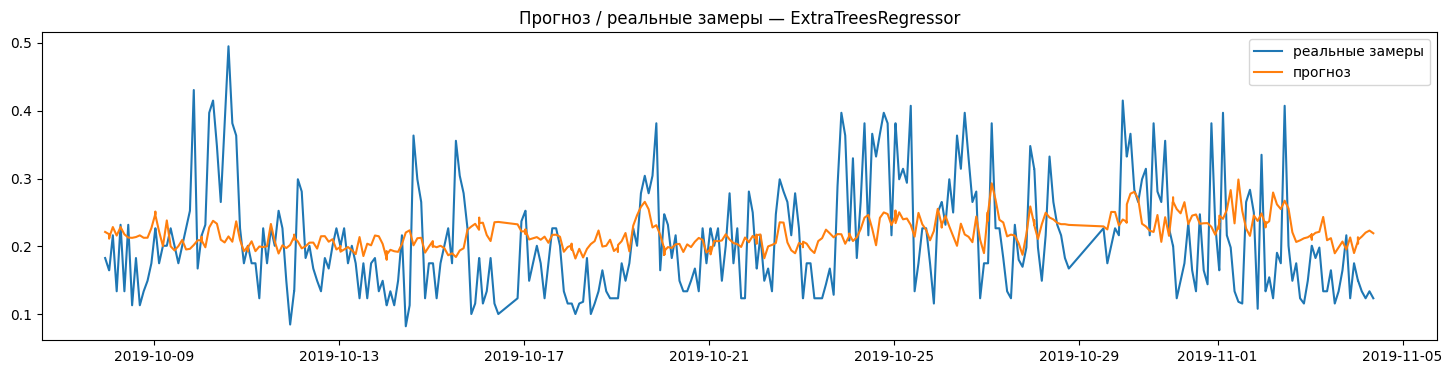

CatBoostRegressor:
 - Нормальность (p-value): 4.897950847598665e-11  вывод: не норм.
 - Автокорреляция (Дарбин-Уотсон): 0.8415040425881906  вывод: есть
 - Гетероскедастичность (p-value): 3.8723741314629496e-05  вывод: есть


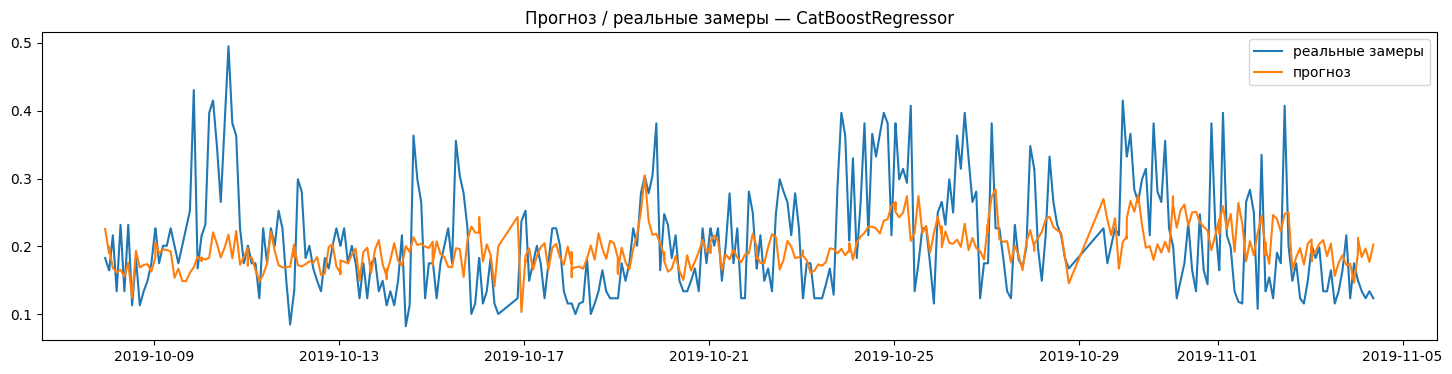

In [206]:
# Провести анализ остатков (нормальность, автокорреляция, гетероскедастичность)
# Визуализировать прогнозы против реальных лабораторных замеров в динамике
import scipy.stats as stats
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.diagnostic import het_breuschpagan
import statsmodels.api as sm

def get_analize_remains(y_test: np.ndarray, y_pred: np.ndarray, model_name: str) -> None:
    '''Анализ остатков: нормальность, автокорреляция, гетероскедастичность'''
    residuals = y_test - y_pred

    _, p_normal = stats.shapiro(residuals[:5000])
    dw = durbin_watson(residuals)
    _, p_het, _, _ = het_breuschpagan(residuals, sm.add_constant(y_pred))

    print(f"{model_name}:")
    print(" - Нормальность (p-value):", p_normal, " вывод:", "норм." if p_normal > 0.05 else "не норм.")
    print(" - Автокорреляция (Дарбин-Уотсон):", dw, " вывод:", "нет" if 1.5 < dw < 2.5 else "есть")
    print(" - Гетероскедастичность (p-value):", p_het, " вывод:", "есть" if p_het < 0.05 else "нет")

def draw_predictions(y_test: pd.Series, y_pred: np.ndarray, model_name: str) -> None:
    '''Визуализация прогнозов против реальных замеров'''
    plt.figure(figsize=(18, 4))
    plt.plot(y_test.index, y_test.values, label="реальные замеры")
    plt.plot(y_test.index, y_pred, label="прогноз")
    plt.title(f"Прогноз / реальные замеры — {model_name}")
    plt.legend()
    plt.show()

# Ridge
get_analize_remains(y_test=y_test, y_pred=y_pred_ridge, model_name="Ridge")
draw_predictions(y_test=y_test, y_pred=y_pred_ridge, model_name="Ridge")
# ExtraTreesRegressor
get_analize_remains(y_test=y_test, y_pred=y_pred_et, model_name="ExtraTreesRegressor")
draw_predictions(y_test=y_test, y_pred=y_pred_et, model_name="ExtraTreesRegressor")
# CatBoostRegressor
get_analize_remains(y_test=y_test, y_pred=y_pred_cat, model_name="CatBoostRegressor")
draw_predictions(y_test=y_test, y_pred=y_pred_cat, model_name="CatBoostRegressor")

Все три модели показали одинаковую картину:
- Нормальность — остатки не нормально распределены (p-value близок к нулю). Это типично для промышленных данных с выбросами и нерегулярными замерами.
- Автокорреляция — значение Дарбина-Уотсона примерно 0.7-0.84 говорит о сильной положительной автокорреляции остатков. Модели не улавливают временную зависимость в данных — соседние ошибки похожи друг на друга.
- Гетероскедастичность — есть у всех моделей. Разброс ошибок неодинаков — в одних режимах работы печи модели ошибаются больше чем в других.
- Автокорреляция остатков говорит о том, что модели недостаточно учитывают временную структуру данных. Это можно улучшить добавив больше лаговых признаков.

In [207]:
# Оценить важность признаков (SHAP, permutation importance) и интерпретировать физические закономерности
import shap
from sklearn.inspection import permutation_importance

def get_permutation_importance(model, X_test: pd.DataFrame, y_test: pd.Series, model_name: str) -> None:
    '''Важность признаков через permutation importance'''
    result = permutation_importance(model, X_test, y_test, n_repeats=5, random_state=42, n_jobs=-1)
    
    importance_df = pd.DataFrame({
        "feature": X_test.columns,
        "importance": result.importances_mean
    }).sort_values("importance", ascending=False)
    
    print(model_name)
    print(importance_df.head(5))

# Ridge
get_permutation_importance(model=ridge, y_test=y_test, X_test=X_test, model_name="Ridge")
print()
# ExtraTreesRegressor
get_permutation_importance(model=et, y_test=y_test, X_test=X_test, model_name="ExtraTreesRegressor")
print()
# CatBoostRegressor
get_permutation_importance(model=cat, y_test=y_test, X_test=X_test, model_name="CatBoostRegressor")
print()

Ridge
               feature  importance
7          telemetry_7    0.064908
20  telemetry_0_mean60    0.017250
22   telemetry_0_min60    0.016129
23   telemetry_0_max60    0.006924
19   telemetry_0_max10    0.005605

ExtraTreesRegressor
               feature  importance
25  telemetry_0_std120    0.015910
12   telemetry_0_lag90    0.013491
21   telemetry_0_std60    0.012265
2          telemetry_2    0.011270
18   telemetry_0_min10    0.011109

CatBoostRegressor
               feature  importance
19   telemetry_0_max10    0.025196
22   telemetry_0_min60    0.024339
18   telemetry_0_min10    0.020189
37  telemetry_6_std120    0.018479
20  telemetry_0_mean60    0.017423



- Ridge — главный признак telemetry_7 с большим отрывом (0.065). Линейная модель опирается на один сильный сигнал.
- ExtraTrees и CatBoost — важность распределена равномернее. Доминирует telemetry_0 в разных вариациях — скользящие статистики, лаги, минимумы/максимумы. Это подтверждает что telemetry_0 наиболее информативный датчик.
- Физическая интерпретация: модели смотрят не на мгновенное значение датчика, а на его поведение за последние 10-60 минут (min, max, std, mean) — это логично для процесса обжига. Концентрация продукта зависит от всего процесса работы печи, а не только от текущего момента.

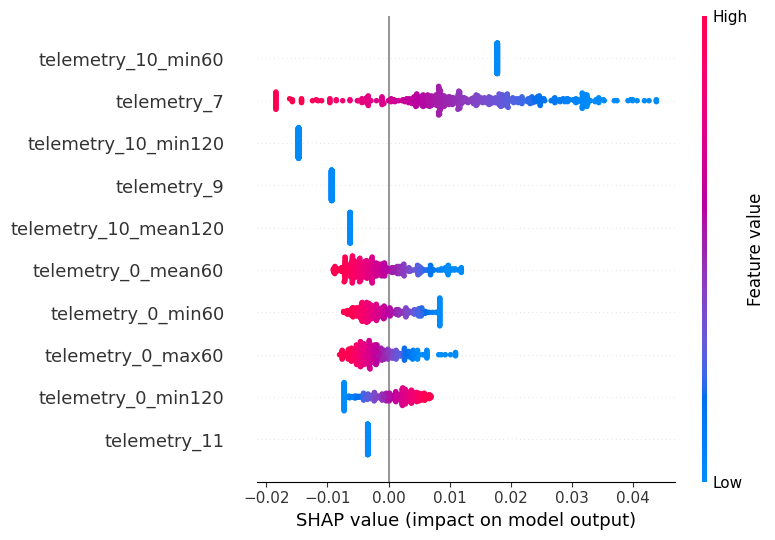

In [208]:
# Ridge
explainer_ridge = shap.LinearExplainer(ridge, X_train)
shap_values_ridge = explainer_ridge.shap_values(X_test)
shap.summary_plot(shap_values_ridge, X_test, max_display=10)
plt.show()

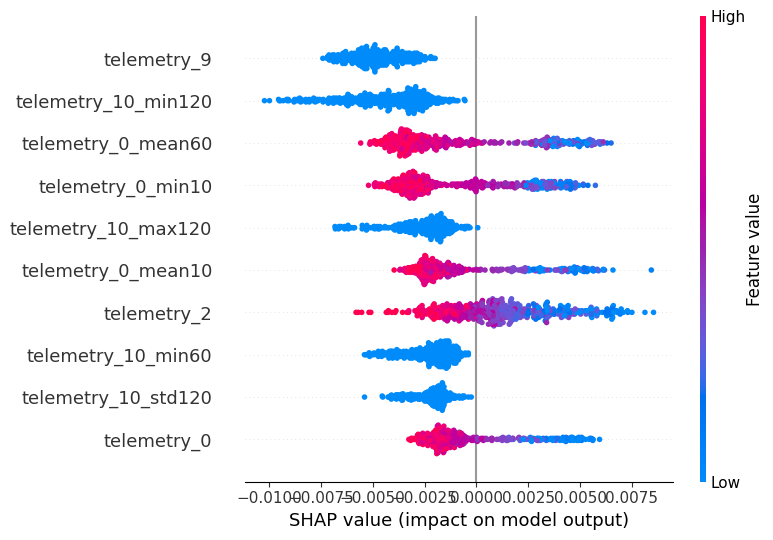

In [209]:
# ExtraTrees
explainer_et = shap.TreeExplainer(et)
shap_values_et = explainer_et.shap_values(X_test)
shap.summary_plot(shap_values_et, X_test, max_display=10)
plt.show()

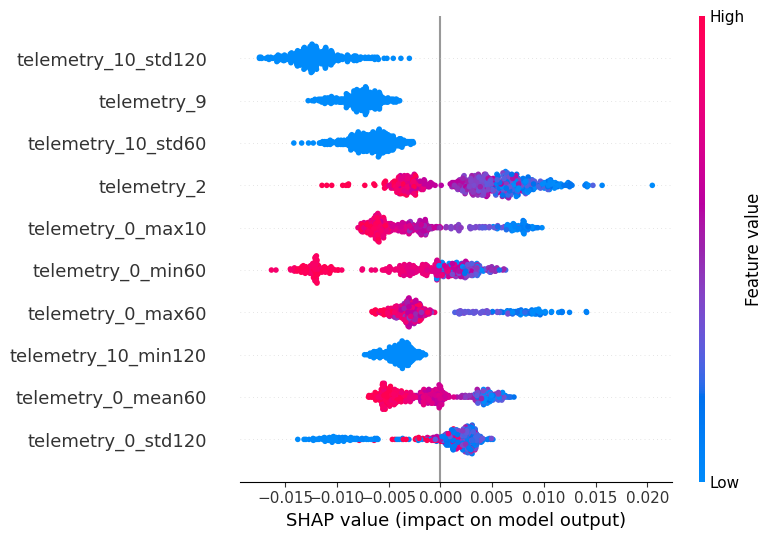

In [210]:
explainer = shap.TreeExplainer(cat)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test, max_display=10)
plt.show()

telemetry_9, telemetry_10 и их скользящие статистики влияют отрицательно во всех моделях — рост этих датчиков снижает прогноз концентрации.

In [211]:
# Сравнить модели по информационным критериям (AIC/BIC для статистических моделей) и вычислительной эффективности
import time

models = {"Ridge": ridge, "ExtraTrees": et, "CatBoost": cat}

for name, model in models.items():
    start = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start

    start = time.time()
    model.predict(X_test)
    pred_time = time.time() - start

    print(f"{name} — обучение: {train_time:.2f}с, предсказание: {pred_time:.2f}с")

Ridge — обучение: 0.00с, предсказание: 0.00с
ExtraTrees — обучение: 0.23с, предсказание: 0.01с
CatBoost — обучение: 1.60с, предсказание: 0.00с


**Результат:**
- Ridge обучается мгновенно, но показывает худшее качество 
- CatBoost обучается дольше всех (1.57с), однако предсказание такое же быстрое как у Ridge — это важно в производственном контексте, где модель должна выдавать результат в реальном времени. 
- ExtraTrees — компромисс между скоростью и качеством.

**Вывод:**

- для production-среды CatBoost оптимален — время предсказания мгновенное, качество лучшее.